In [11]:
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import yaml
from hashlib import sha1
import uuid

from pftnc.dataset_simulation_config import DatasetSimConfig, load_dataset_gen_config
from datetime import datetime
from tqdm.auto import tqdm
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [12]:
def read_registry(regsitry_path):

    if regsitry_path.exists():

        data = yaml.safe_load(regsitry_path.read_text())

        if data is None:
            data = {"datasets": {}}

        return data

    else:

        return {"datasets": {}}


def validate_registry(base_path, registry):

    base_key = str(base_path)

    disk_versions = {
        p.name for p in base_path.iterdir()
        if p.is_dir()
    } if base_path.exists() else set()

    yaml_versions = set(
        registry.get("datasets", {})
        .get(base_key, {})
        .keys()
    )

    if disk_versions != yaml_versions:

        raise RuntimeError(
            "Dataset registry mismatch\n"
            f"Dataset: {base_key}\n"
            f"Disk versions: {sorted(disk_versions)}\n"
            f"Registry versions: {sorted(yaml_versions)}"
        )


def generate_dataset_version(cfg, site) -> str:
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%SZ%z")

    # stable hash of config - if multiple users created the dataset using same configurations
    cfg_dict = cfg.model_dump(mode="json")
    cfg_json = json.dumps(cfg_dict, sort_keys=True)
    cfg_hash = sha1(cfg_json.encode()).hexdigest()[:8]

    # randomness prevents collisions
    rand = uuid.uuid4().hex[:6]

    return f"{site}_{timestamp}_{cfg_hash}_{rand}"


def register_dataset_version(registry_path, base_path, description, version):

    registry = read_registry(registry_path)

    base_path = str(base_path)

    if "datasets" not in registry:
        registry["datasets"] = {}

    if base_path not in registry["datasets"]:
        registry["datasets"][base_path] = {}

    registry["datasets"][base_path][version] = {

        "path": "/".join([base_path, version]),
        "description": description,
        "created": datetime.utcnow().isoformat()

    }

    registry_path.parent.mkdir(parents=True, exist_ok=True)

    with registry_path.open("w") as f:
        yaml.safe_dump(registry, f, sort_keys=False)


def save_feature_schema(df, path):

    schema = {

        "columns": list(df.columns),
        "n_features": len(df.columns)

    }

    with open(path / "feature_schema.yaml", "w") as f:
        yaml.safe_dump(schema, f)

In [13]:
class Simulation:
    def apply(self, df):
        raise NotImplementedError


class RevisitFrequency(Simulation):

    def __init__(self, columns, freq_days, date_col):
        self.columns = columns
        self.freq_days = freq_days
        self.date_col = date_col

    def apply(self, df):
        df = df.copy()
        unique_dates = sorted(df[self.date_col].unique())
        keep_dates = set(unique_dates[::self.freq_days])
        mask = ~df[self.date_col].isin(keep_dates)
        df.loc[mask, self.columns] = np.nan
        return df


class CloudMask(Simulation):

    def __init__(self, columns, date_col, probs, rng):
        self.columns = columns
        self.date_col = date_col
        self.probs = probs
        self.rng = rng

    def apply(self, df):
        df = df.copy()
        month = df[self.date_col].dt.month
        prob = np.where(
            month.isin([12,1,2]),
            self.probs["winter"],
            np.where(
                month.isin([6,7,8]),
                self.probs["summer"],
                self.probs["default"]
            )
        )
        mask = self.rng.random(len(df)) < prob
        df.loc[mask, self.columns] = np.nan
        return df

class GaussianNoise(Simulation):

    def __init__(self, columns, std, rng):
        self.columns = columns
        self.std = std or 0.01
        self.rng = rng

    def apply(self, df):
        df = df.copy()
        noise = self.rng.normal(
            0,
            self.std,
            size=(len(df), len(self.columns))
        )
        df[self.columns] = df[self.columns] + noise

        return df

def apply_simulations(df, simulations):

    for s in simulations:
        df = s.apply(df)

    return df

In [14]:
def build_simulations(cfg, rng):

    sim_cfg = cfg.simulation

    transforms = []

    all_sensor_cols = []

    for sensor_name, sensor_cfg in sim_cfg.sensors.items():

        columns = sensor_cfg.columns

        transforms.append(
            RevisitFrequency(
                columns=columns,
                freq_days=sensor_cfg.revisit_days,
                date_col=sim_cfg.date_column
            )
        )

        if sensor_cfg.noise_std is not None:

            transforms.append(
                GaussianNoise(
                    columns=columns,
                    std=sensor_cfg.noise_std,
                    rng=rng
                )
            )

        all_sensor_cols.extend(columns)

    transforms.append(
        CloudMask(
            columns=all_sensor_cols,
            date_col=sim_cfg.date_column,
            probs=sim_cfg.cloud_mask,
            rng=rng
        )
    )

    return transforms

In [35]:
def simulate_dataset(cfg, raw_df=None):

    print("Simulating dataset")

    if raw_df is None:
        input_path = cfg.simulation.input_path
    
        print(f"Loading input data from {input_path}")
    
        raw_df = pd.read_csv(input_path, index_col=0)

    raw_df["time"] = pd.to_datetime(raw_df["time"])
    raw_df["date"] = pd.to_datetime(raw_df["date"])

    rng = np.random.default_rng(cfg.project.seed)

    simulations = build_simulations(cfg, rng)

    print("Applying simulations")
    simulated_df = apply_simulations(raw_df, simulations)

    registry = read_registry(cfg.simulation.registry_path)
    validate_registry(cfg.simulation.base_path, registry)
    version = generate_dataset_version(cfg, cfg.simulation.site_name)

    base = cfg.simulation.base_path
    path = base / version
    path.mkdir(parents=True)

    register_dataset_version(cfg.simulation.registry_path, base, cfg.simulation.description, version)

    dataset_path = cfg.simulation.base_path / version


    simulated_df.to_parquet(dataset_path / "simulated.parquet")

    save_feature_schema(simulated_df, dataset_path)

    config_path = dataset_path / "config.yml"

    with open(config_path, "w") as f:
        yaml.safe_dump(
            cfg.model_dump(mode="json"),
            f,
            sort_keys=False,
        )
            
    print(f"Simulated data available at")

    return dataset_path

In [36]:
def check_target_quality(df, target_cols):
    """
    Raise if any target column contains NaN or negative values.

    Call this on the prepared dataframe before build_dataset.
    Negative concentrations are physically invalid and cause NaN in the
    log-fractions transform; NaN targets have no valid label.
    """
    issues = {}
    nan_counts = df[target_cols].isna().sum()
    neg_counts = (df[target_cols] < 0).sum()
    if nan_counts.any():
        issues["nan"] = nan_counts[nan_counts > 0].to_dict()
    if neg_counts.any():
        issues["negative"] = neg_counts[neg_counts > 0].to_dict()
    if issues:
        raise ValueError(
            "Target quality check failed:\n"
            + "\n".join(f"  {k}: {v}" for k, v in issues.items())
            + "\nFix the data before calling build_dataset."
        )
    print(f"Target quality OK — {len(df)} rows, no NaN or negative values in targets.")



In [37]:
config_path = Path("../config/dataset_simulation_config.yml").resolve()

dataset_sim_config = load_dataset_gen_config(config_path)  

In [38]:
dataset_sim_config

DatasetSimConfig(project=ProjectConfig(seed=42), simulation=SimulationConfig(enabled=True, base_path=PosixPath('/home/yogesh/Projects/BC/pftnc/notebooks/data/simulated/elbe_bunthaus_new'), registry_path=PosixPath('/home/yogesh/Projects/BC/pftnc/notebooks/data/simulated/elbe_bunthaus_new/simulated.yaml'), description='First version of pft simulated dataset for the elbe river bunthaus station including log-fraction ratios', site_name='elbe_bunthaus', sensors={'chime': SensorSimConfig(revisit_days=11, noise_std=None, columns=['chime_diatoms_ug_per_l', 'chime_cyanobacteria_ug_per_l', 'chime_others_ug_per_l']), 'lstm': SensorSimConfig(revisit_days=2, noise_std=None, columns=['lstm_lswt_c']), 's2': SensorSimConfig(revisit_days=5, noise_std=0.03, columns=['s2_chl_ug_per_l', 's2_tur_mg_per_l', 's2_cdom_1_per_m']), 's3': SensorSimConfig(revisit_days=1, noise_std=0.04, columns=['s3_chl_ug_per_l', 's3_tur_mg_per_l', 's3_cdom_1_per_m'])}, cloud_mask={'winter': 0.75, 'summer': 0.25, 'default': 0.5}

In [40]:
# output_path = simulate_dataset(dataset_sim_config, sanitized_df)
output_path = simulate_dataset(dataset_sim_config)
output_path

Simulating dataset
Loading input data from /home/yogesh/Projects/BC/aquatime-rnd/data/elbe_river/7.0_pftnc/elbe-river_bunthaus_v0.3_sanitized.csv
Applying simulations
Simulated data available at


/tmp/ipykernel_101097/3508844780.py:72: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created": datetime.utcnow().isoformat()


PosixPath('/home/yogesh/Projects/BC/pftnc/notebooks/data/simulated/elbe_bunthaus_new/elbe_bunthaus_20260521T222205Z_64790d36_91d052')

## Quick dataset validation (manual)

In [38]:
input_data = pd.read_parquet(str(output_path) + "/simulated.parquet")

In [39]:
for c in input_data.columns:
    print(c)

date
time
site_lat
site_lon
chime_diatoms_ug_per_l
chime_cyanobacteria_ug_per_l
chime_others_ug_per_l
lstm_lswt_c
s2_chl_ug_per_l
s2_tur_mg_per_l
s2_cdom_1_per_m
s3_chl_ug_per_l
s3_tur_mg_per_l
s3_cdom_1_per_m
diatoms_ug_per_l
cyanobacterial_ug_per_l
others_ug_per_l


In [40]:
input_data.head(50)

,date,time,site_lat,site_lon,chime_diatoms_ug_per_l,chime_cyanobacteria_ug_per_l,chime_others_ug_per_l,lstm_lswt_c,s2_chl_ug_per_l,s2_tur_mg_per_l,s2_cdom_1_per_m,s3_chl_ug_per_l,s3_tur_mg_per_l,s3_cdom_1_per_m,diatoms_ug_per_l,cyanobacterial_ug_per_l,others_ug_per_l
site,,,,,,,,,,,,,,,,,
elbe-river_bunthaus_v0.3,2015-01-01,2015-01-01 12:00:00,53.461787,10.064451,0.0,0.07,1.31,2.905000,1.389142,20.937013,0.540427,1.306116,20.955675,0.469852,0.000000,0.070000,1.310000
elbe-river_bunthaus_v0.3,2015-01-02,2015-01-02 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.360000,1.540000
elbe-river_bunthaus_v0.3,2015-01-03,2015-01-03 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.960000
elbe-river_bunthaus_v0.3,2015-01-04,2015-01-04 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.270000,0.220000,0.870000
elbe-river_bunthaus_v0.3,2015-01-05,2015-01-05 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.690000,0.320000,1.640000
elbe-river_bunthaus_v0.3,2015-01-06,2015-01-06 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,1.904221,17.005813,0.539090,1.939167,16.997390,0.636432,0.000000,0.000000,1.930000
elbe-river_bunthaus_v0.3,2015-01-07,2015-01-07 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029306,0.015000,2.590352
elbe-river_bunthaus_v0.3,2015-01-08,2015-01-08 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,2.318265
elbe-river_bunthaus_v0.3,2015-01-09,2015-01-09 12:00:00,53.461787,10.064451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.460000,0.000000,2.460000


<Axes: xlabel='date', ylabel='s2_chl_ug_per_l'>

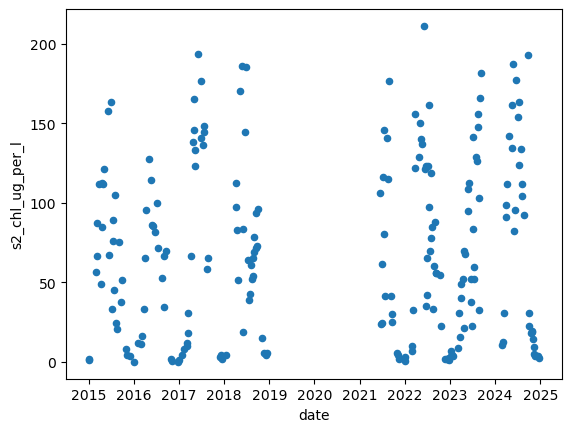

In [41]:
input_data.plot.scatter(x="date", y="s2_chl_ug_per_l")

<Axes: xlabel='date', ylabel='lstm_lswt_c'>

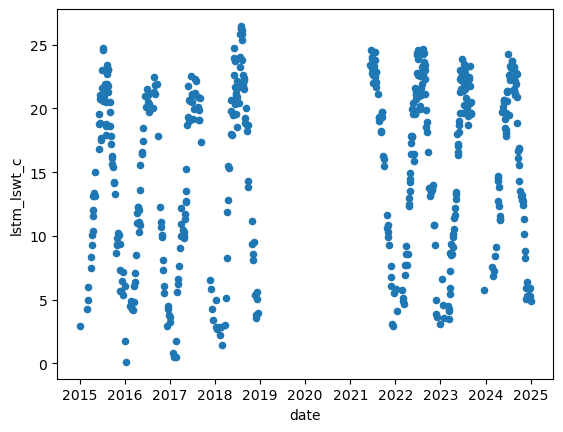

In [42]:
input_data.plot.scatter(x="date", y="lstm_lswt_c")